# Notebook 03 — EDA: Master Data

**Mục tiêu**: Phân tích tổng quan 3 bảng master chính
- **Products**: Danh mục sản phẩm, phân phối giá, top category
- **Customers**: Phân bổ địa lý, phân khúc khách hàng
- **Promotions**: Tần suất, loại hình, hiệu quả khuyến mãi

**Output**: 3 Dashboard Power BI (export figures từ notebook này làm tham khảo)

**Tương ứng báo cáo**: Phần 2 — Chương 4.2 (Phân tích theo đối tượng)

In [1]:
import sys
sys.path.append('..')

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from src.data_loader import load_processed
from pathlib import Path

FIG_DIR = Path('../outputs/figures/eda')
FIG_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style='whitegrid', palette='Set2')
%matplotlib inline

In [2]:
products   = load_processed('products_clean.csv')
customers  = load_processed('customers_clean.csv')
promotions = load_processed('promotions_clean.csv')
geography  = load_processed('geography_clean.csv')

## 1. Sản phẩm (Products)

**Câu hỏi cần trả lời**:
- Doanh nghiệp kinh doanh bao nhiêu loại sản phẩm? Phân theo category nào?
- Phân phối giá bán như thế nào?
- Sản phẩm nào có biên lợi nhuận cao nhất?

Unique product names: 2172
Unique product ids (variants): 2412


,unique_products_name,variants
category,,
Streetwear,1239,1320
Outdoor,584,743
Casual,201,201
GenZ,148,148


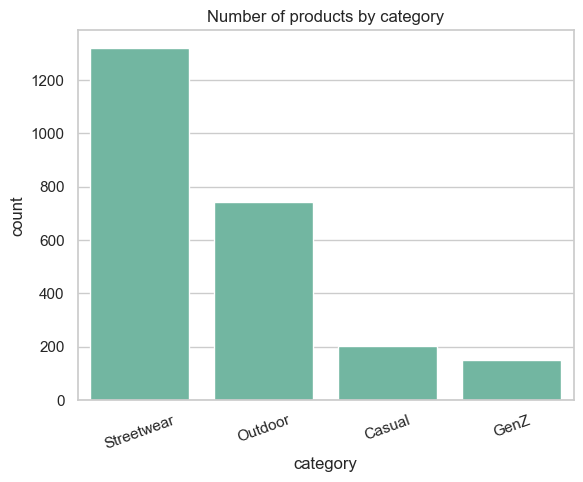

In [7]:
# 1, Number of products by category 
n_names = products['product_name'].nunique()
n_ids = products['product_id'].nunique()
by_category = (
    products.groupby('category')
    .agg(unique_products_name = ('product_name', 'nunique'), variants = ('product_id', 'count'))
    .sort_values('variants', ascending = False)
)

print(f"Unique product names: {n_names}")
print(f"Unique product ids (variants): {n_ids}")
display(by_category)


sns.countplot(data = products, x = 'category', order = by_category.index)
plt.title('Number of products by category')
plt.xticks(rotation=20)
plt.show()

**Nhận xét:** Streetwear chiếm nhiều nhất, Outdoor đứng thứ hai; Casual và GenZ ít hơn rõ rệt. Có thể ưu tiên tồn kho/marketing cho Streetwear và Outdoor. => Có thể Streetwear là sản phẩm chủ lực của công ty nên ưu tiên đa dạng sản phẩm và kích cỡ.

count     2412.000000
mean      4928.216231
std       4776.737669
min          9.056594
25%         59.444924
50%       4399.605000
75%       7720.513784
max      40950.000000
Name: price, dtype: float64

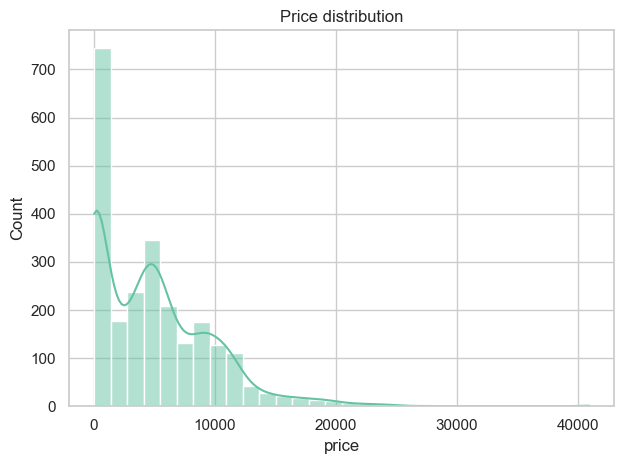

In [11]:
# 2, Price distribution
display(products['price'].describe())

sns.histplot(data = products, x = 'price', bins = 30, kde = True)
plt.title('Price distribution')
plt.tight_layout()
plt.show()

**Nhận xét:** Giá bán phân bố lệch phải, phần lớn sản phẩm ở mức giá thấp-đến-trung bình; chỉ một số ít sản phẩm giá rất cao. => Doanh nghiệp chủ yếu bán những sản phẩm giá rẻ, để thu hút lượng lớn khách hàng.

In [14]:
# 3, Profit margin 

prod = products.copy()
prod['margin'] = prod['price'] - prod['cogs']
prod['margin_pct'] = prod['margin'] / prod['price'] * 100

top_abs = prod.sort_values('margin', ascending = False).head(10)
top_pct = prod.sort_values('margin_pct', ascending = False).head(10)

cols = ['product_id','product_name','category','price','cogs','margin','margin_pct']
print('Top margin (absolute):')
display(top_abs[cols])
print('Top margin (%):')
display(top_pct[cols]) 

Top margin (absolute):


,product_id,product_name,category,price,cogs,margin,margin_pct
661,296,LotusWear UE-17,Streetwear,27716.850000,14598.464895,13118.385105,47.33
674,309,LotusWear UE-30,Streetwear,40950.000000,30319.380000,10630.620000,25.96
427,519,SaigonFlex UE-07,Streetwear,19526.850000,9948.930075,9577.919925,49.05
832,476,SaigonFlex UM-81,Streetwear,23472.730465,14022.609180,9450.121285,40.26
761,405,SaigonFlex UM-10,Streetwear,22994.370000,14155.334172,8839.035828,38.44
780,424,SaigonFlex UM-29,Streetwear,20475.451545,12027.280238,8448.171307,41.26
912,118,DragonWear UM-45,Streetwear,18868.500000,10428.619950,8439.880050,44.73
123,659,SaigonFlex UC-24,Streetwear,18102.505135,10184.469389,7918.035746,43.74
933,208,IndigoViet UM-10,Streetwear,17521.536667,9855.864375,7665.672292,43.75
860,504,SaigonFlex UM-09,Streetwear,22059.311538,14451.054989,7608.256550,34.49


Top margin (%):


,product_id,product_name,category,price,cogs,margin,margin_pct
281,1689,NamStyle UC-01,Streetwear,2708.370000,1355.268348,1353.101652,49.96
1671,1569,VietMode RS-07,Outdoor,5039.370000,2522.708622,2516.661378,49.94
177,944,HanoiStreet UC-07,Streetwear,8971.200000,4491.879840,4479.320160,49.93
222,989,HanoiStreet UC-52,Streetwear,5262.471266,2638.603093,2623.868173,49.86
1836,735,HanoiStreet RP-23,Outdoor,4615.655408,2314.751187,2300.904221,49.85
2040,1099,MekongFit RP-45,Outdoor,497.070000,249.280605,247.789395,49.85
1654,2402,VietMotion YY-11,GenZ,3733.948734,1874.442264,1859.506470,49.80
1422,2102,PhoenixWear MA-01,Casual,6299.370000,3167.323236,3132.046764,49.72
2330,1513,VietMode RP-05,Outdoor,4848.653793,2439.357723,2409.296070,49.69
590,2060,UrbanVN UE-20,Streetwear,4438.989403,2234.587265,2204.402138,49.66


**Nhận xét**: Một số sản phẩm như NamStyle uc-01, VietMode RS-07 và HanoiStreet UC-07 mang lại biên lợi nhuận lớn, gần đạt 50%, và đều đến từ hai danh mục trọng điểm của doanh nghiệp là Streetwear và Outdoor.

## 2. Khách hàng (Customers)

**Câu hỏi cần trả lời**:
- Phân bổ khách hàng theo tỉnh/thành?
- Phân khúc tuổi, giới tính?
- Khách hàng mới vs quay lại?

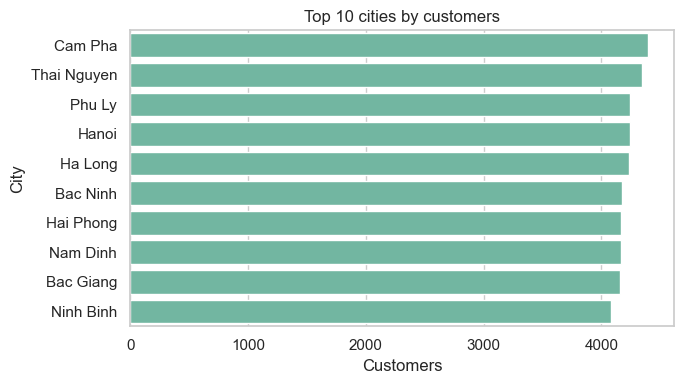

In [15]:
# 1) Customers by city (top 10)
city_counts = customers['city'].value_counts().head(10)
plt.figure(figsize=(7, 4))
sns.barplot(x=city_counts.values, y=city_counts.index, orient='h')
plt.title('Top 10 cities by customers')
plt.xlabel('Customers')
plt.ylabel('City')
plt.tight_layout()
plt.show()

**Nhận xét:** Khách hàng tập trung ở một vài thành phố lớn; nhóm top 10 chiếm phần lớn số lượng.

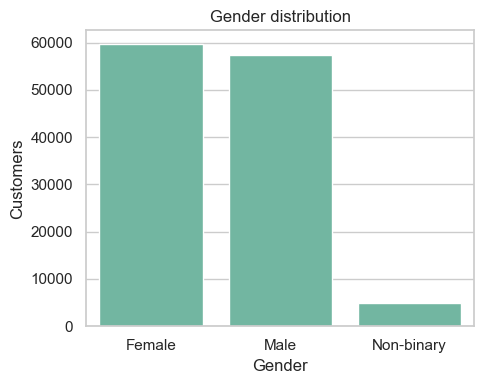

In [16]:
# 2) Gender distribution
plt.figure(figsize=(5, 4))
sns.countplot(data=customers, x='gender')
plt.title('Gender distribution')
plt.xlabel('Gender')
plt.ylabel('Customers')
plt.tight_layout()
plt.show()

**Nhận xét:** Giới tính phân bố tương đối cân bằng/ lệch nhẹ.

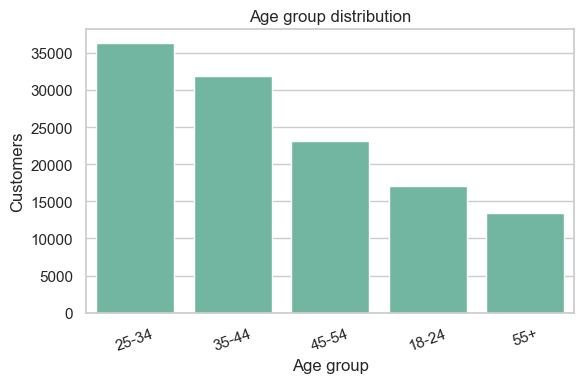

In [17]:
# 3) Age group distribution
age_order = customers['age_group'].value_counts().index
plt.figure(figsize=(6, 4))
sns.countplot(data=customers, x='age_group', order=age_order)
plt.title('Age group distribution')
plt.xlabel('Age group')
plt.ylabel('Customers')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

**Nhận xét:** Nhóm tuổi chủ đạo tập trung ở vài nhóm tương đối rõ nét. Đặc biệt, với tính chất là sản phẩm ngành thời trang, nên nhóm tuổi trẻ và trung niên từ 25-44 sở hữu lượng lớn khách hàng.

## 3. Khuyến mãi (Promotions)

**Câu hỏi cần trả lời**:
- Bao nhiêu chương trình khuyến mãi? Theo loại hình nào?
- Tần suất chạy khuyến mãi theo tháng/quý?
- Discount rate trung bình là bao nhiêu?

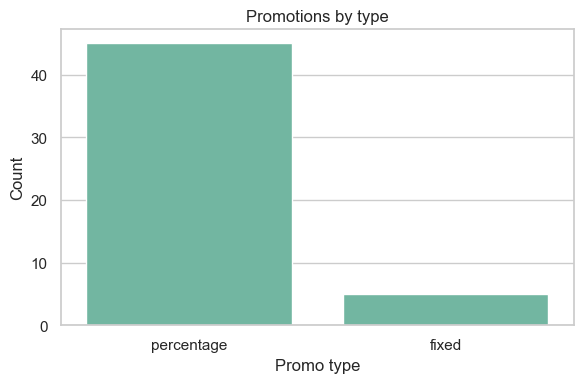

In [18]:
# 1) Promotions by type
type_counts = promotions['promo_type'].value_counts()
plt.figure(figsize=(6, 4))
sns.barplot(x=type_counts.index, y=type_counts.values)
plt.title('Promotions by type')
plt.xlabel('Promo type')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Nhận xét:** Có hai loại khuyến mãi: Percentage và fixed, khuyến mãi percentage được ưu tiên sử dụng nhiều hơn.

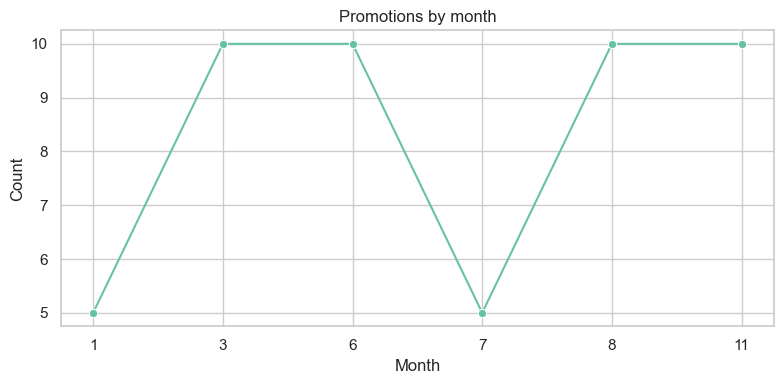

In [22]:
# 2) Promotion frequency by month (ignore year)
promo_dates = promotions.copy()
promo_dates['start_date'] = pd.to_datetime(promo_dates['start_date'])
promo_month = promo_dates['start_date'].dt.month.value_counts().sort_index()
month_labels = [str(m) for m in promo_month.index]

plt.figure(figsize=(8, 4))
sns.lineplot(x=month_labels, y=promo_month.values, marker='o')
plt.title('Promotions by month')
plt.xlabel('Month')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

**Nhận xét:** Tần suất khuyến mãi có tính chu kỳ theo tháng. Doanh nghiệp tập trung khuyến mãi, trải dài các tháng trong năm.

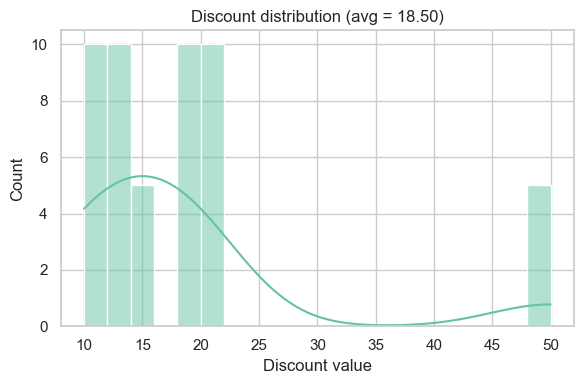

In [20]:
# 3) Discount distribution
avg_discount = promotions['discount_value'].mean()
plt.figure(figsize=(6, 4))
sns.histplot(data=promotions, x='discount_value', bins=20, kde=True)
plt.title(f'Discount distribution (avg = {avg_discount:.2f})')
plt.xlabel('Discount value')
plt.tight_layout()
plt.show()

**Nhận xét:** Discount tập trung quanh mức trung bình từ 10-20%, một số ít chương trình có mức giảm cao bất thường (50) nhưng là tính bằng đơn vị đồng. => Chương trình Urban Blowout.